Digital Business University of Applied Sciences

Data Science und Management (M. Sc.)

DAMI01 / DATA01 Data Analytics

Prof. Dr. Daniel Ambach

Julia Schmid (200022)

***
# Time-Series-Clustering
# Teil 1: Business & Data Understanding

***
## Phase 1: Geschäftsverständnis
***

**Problemstellung**

Die Kundensegmentierung ist ein etabliertes Verfahren zur Analyse und Steuerung von Kundenbeziehungen. Klassische Ansätze basieren jedoch überwiegend auf aggregierten Kennzahlen und statischen Merkmalen, wodurch die zeitliche Dynamik weitgehend unberücksichtigt bleibt. Transaktionsdaten weisen eine zeitliche Ordnung auf, die sich mit konventionellen Segmentierungsmethoden nur begrenzt nutzen lässt. Es stellt sich daher die Frage, welche Time Series Clustering (TSC)-Methode auf Basis von Transaktionsdaten optimal validierte Kundengruppen identifizieren lässt.

**Ziel der Analyse**

Ziel dieser Analyse ist es, auf Basis von Transaktionsdaten diejenige Time Series Clustering-Methode zu identifizieren, die eine optimal validierte Kundengruppierung liefert. Dazu werden mehrere TSC-Methoden (k-Means, agglomeratives Clustering, k-Medoids, Fuzzy C-Means (FCM), Spectral Clustering  und Density-Based Spatial Clustering of Applications with Noise (DBSCAN)), jeweils mit unterschiedlichen Dynamic Time Warping (DTW)-Distanzvarianten, angewendet und systematisch verglichen. Die resultierenden Segmente werden einer Validierungsanalyse unterzogen, indem geprüft wird, ob sie hinsichtlich ergänzender, nicht in das Clustering eingeflossener Kundenmerkmale signifikante Unterschiede aufweisen. Auf diese Weise lässt sich bewerten, welche Methode validierte Kundensegmente hervorbringt.

**Dateninhalt**

Grundlage der Untersuchung bildet das Financial Transactions Dataset von Kaggle, das umfassende Angaben zu finanziellen Transaktionen von Kartenkunden bereitstellt. Neben Informationen zu Transaktionszeitpunkt, Betrag, Händler und Art der Transaktion umfasst der Datensatz auch kartenbezogene Merkmale wie Kartentyp und Kreditlimit. Ein ergänzender MCC-Datensatz ordnet die Händler über standardisierte Branchencodes ein. Zu den rund 2.000 Kunden sind darüber hinaus demografische sowie kontobezogene Angaben verfügbar. Der Fraud-Datensatz, welcher den einzelnen Transaktionen ein Betrugskennzeichen zuweist, findet im Rahmen dieser Clusteranalyse keine Anwendung. <br>
Eine genaue Auflistung der in den Daten enthaltenen Variablen ist der Datei **[DATA_INFORMATION](../DATA_INFORMATION.md)** zu entnehmen.

Quelle: Vazquez, V. V. Financial Transactions Dataset: Analytics. Abgerufen am 20.02.2026 von https://www.kaggle.com/datasets/computingvictor/transactions-fraud-datasets

***
## Phase 2: Datenverständnis
***

In [1]:
# Imports
import kagglehub
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import seaborn as sns
from pathlib import Path

# Imports Parameter
from parameter import INPUT_PATH, INPUT_ORIGIN_PATH

/Users/juliaschmid/Desktop/Neuer Ordner 2/DAMI01_DATA01/dami01_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Einstellung, dass alle Spalten eines Datensatzes angezeigt werden
pd.set_option("display.max_columns", None)

### **Daten Download**

In [3]:
# Daten von Kaggle downloaden
# Quelle: Vazquez, V. V. Financial Transactions Dataset: Analytics.
# Abgerufen am 20.02.2026 von
# https://www.kaggle.com/datasets/computingvictor/transactions-fraud-datasets
kagglehub.dataset_download(
    "computingvictor/transactions-fraud-datasets",
    output_dir=INPUT_ORIGIN_PATH,
    force_download=True
)

100%|██████████| 348M/348M [00:10<00:00, 35.4MB/s] 

Extracting files...


PosixPath('data/origin')

### Transaktionsdaten

In [4]:
path_temp = INPUT_ORIGIN_PATH / "transactions_data.csv"
# Transaktionsdaten als DataFrame speichern
df_transactions = pd.read_csv(path_temp)
print(df_transactions.shape)  # Anzahl der Zeilen/Spalten ausgeben
df_transactions.head()  # Ersten 5 Einträge anzeigen

(13305915, 12)


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


In [5]:
# ID-Spalte anpassen für eine eindeutige Zuordnung
df_transactions = df_transactions.rename(columns={"id": "id_transaction"})

### MCC-Daten

In [6]:
path_temp = INPUT_ORIGIN_PATH / "mcc_codes.json"
# MCC-Daten als DataFrame speichern
df_mcc = pd.read_json(
    path_temp, typ="series", encoding="utf-8"
)
print(df_mcc.shape)  # Anzahl der Zeilen/Spalten ausgeben
df_mcc.head()  # Ersten 5 Einträge anzeigen

(109,)


5812           Eating Places and Restaurants
5541                        Service Stations
7996    Amusement Parks, Carnivals, Circuses
5411            Grocery Stores, Supermarkets
4784                   Tolls and Bridge Fees
dtype: str

In [7]:
# Spaltenbezeichnung anpassen
df_mcc = df_mcc.rename_axis("mcc").reset_index(name="description")

# MCC-Daten mit den Transaktionsdaten zusammenführen
df_transactions = df_transactions.merge(
    df_mcc, how="left", on="mcc"
)

### Kartendaten

In [8]:
path_temp = INPUT_ORIGIN_PATH / "cards_data.csv"
# Kartendaten als DataFrame speichern
df_cards = pd.read_csv(path_temp)
print(df_cards.shape)  # Anzahl der Zeilen/Spalten ausgeben
df_cards.head()  # Ersten 5 Einträge anzeigen

(6146, 13)


,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


In [9]:
# ID-Spalte anpassen für eine eindeutige Zuordnung
df_cards = df_cards.rename(columns={"id": "id_cards"})

# Kartendaten mit den Transaktionsdaten zusammenführen
df_transactions = df_transactions.merge(
    df_cards, how="left", on="client_id"
)

### Kundendaten

In [10]:
path_temp = INPUT_ORIGIN_PATH / "users_data.csv"
# Kundeninformationen als DataFrame speichern
df_user = pd.read_csv(path_temp)
print(df_user.shape)  # Anzahl der Zeilen/Spalten ausgeben
df_user.head()  # Ersten 5 Einträge anzeigen

(2000, 14)


,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1


In [11]:
# ID-Spalte anpassen für eine eindeutige Zuordnung
df_user = df_user.rename(columns={"id": "id_user"})

# Kundendaten mit den Transaktionsdaten zusammenführen
df_transactions = df_transactions.merge(
    df_user, how="left", left_on="client_id", right_on="id_user"
)

### **Daten Speicherung**

In [12]:
INPUT_PATH = Path(INPUT_PATH)
path_temp = INPUT_PATH / "data_acquisition.csv"
# Ordner erstellen (falls nicht vorhanden)
INPUT_PATH.mkdir(parents=True, exist_ok=True)
# Daten speichern
df_transactions.to_csv(path_temp, index=False)

***
## Phase 2: Explorative Datenanalyse (EDA)
***

### Kategorische Variablen

In [18]:
# Bestimmung der kategorischen Variablen
categorical_var = df_transactions.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

# Ausgabe der kategorischen Variablennamen (10 Variablen pro Zeile)
print("Kategorische Variablen:")
for i in range(0, len(categorical_var), 10):
    print(", ".join(categorical_var[i:i+10]))

Kategorische Variablen:
date, amount, use_chip, merchant_city, merchant_state, errors, description, card_brand, card_type, expires
has_chip, credit_limit, acct_open_date, card_on_dark_web, gender, address, per_capita_income, yearly_income, total_debt


In [19]:
# Für Variablen, die mehr als 100 Ausprägungen pro Kategorie haben
# wird die Anzahl der unterschiedlichen Ausprägungen ausgeben,
# ansonsten werden die unterschiedlichen Ausprägungen inklusive der
# Anzahl
for i in categorical_var:
    n_unique_values = df_transactions[i].nunique()
    # Ausgabe der unerschiedlichen Ausprägungen inkl. Anzahl
    if n_unique_values < 100:
        print(df_transactions[i].value_counts())
        print("")
    # Anzahl der unterschiedlichen Ausprägungen ausgeben
    else:
        print(i)
        print(f"Anzahl der verschiedenen Werte: {n_unique_values}")
        print("")

date
Anzahl der verschiedenen Werte: 4136496

amount
Anzahl der verschiedenen Werte: 81161

use_chip
Swipe Transaction     26895623
Chip Transaction      18309550
Online Transaction     5910164
Name: count, dtype: int64

merchant_city
Anzahl der verschiedenen Werte: 12492

merchant_state
Anzahl der verschiedenen Werte: 199

errors
Insufficient Balance                                   501252
Bad PIN                                                123075
Technical Glitch                                       101099
Bad Card Number                                         29628
Bad CVV                                                 23199
Bad Expiration                                          22999
Bad Zipcode                                              4143
Bad PIN,Insufficient Balance                             1140
Insufficient Balance,Technical Glitch                     912
Bad PIN,Technical Glitch                                  272
Bad Card Number,Insufficient Balance           

In [20]:
# Zeitraum anzeigen (Min/Max Datum)
print(f"Minimales Datum {df_transactions['date'].min()}")
print(f"Maximales Datum {df_transactions['date'].max()}")

Minimales Datum 2010-01-01 00:01:00
Maximales Datum 2019-10-31 23:59:00


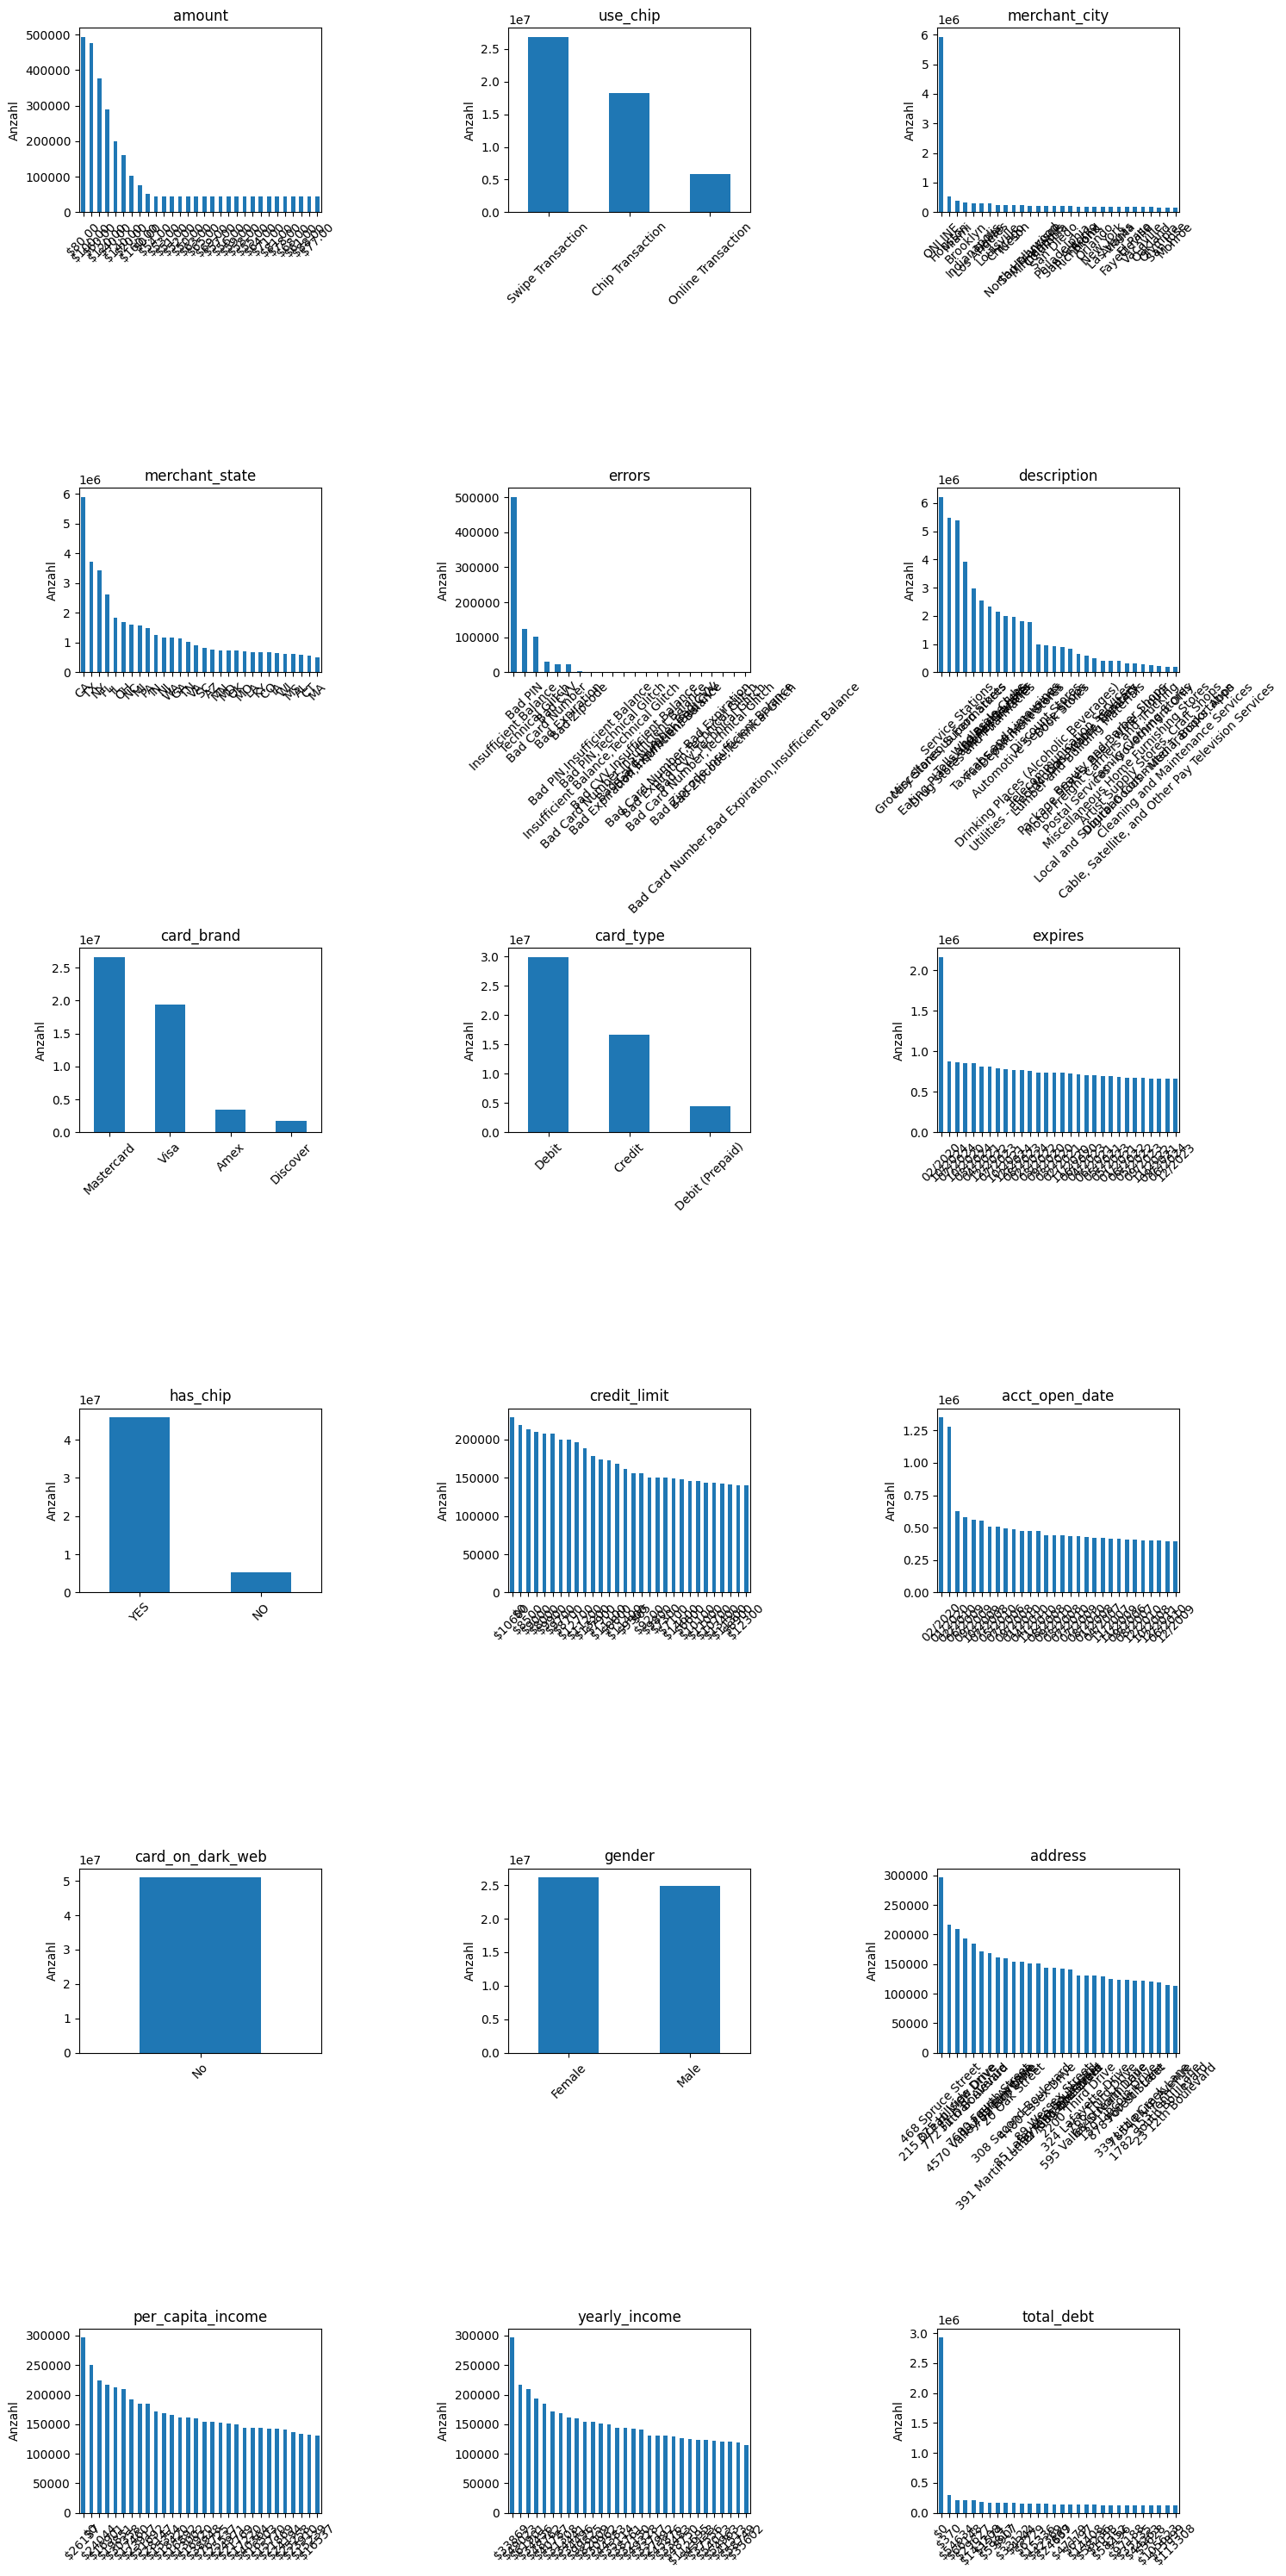

In [21]:
# Barplot: Häufigkeitsverteilung der Top 30 Ausprägungen pro kategorische Variable

categorical_var = [
    col for col in categorical_var
    # Variable date nicht verwenden, da zu viele unterschiedliche Werte vorliegen
    if col not in ["date"]
]

# Anzeige: 3 Plots nebeneinander
n_cols = 3
n_rows = math.ceil(len(categorical_var) / n_cols)
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(15, 5*n_rows)
)
axes = axes.flatten()
counter = 0

for i in categorical_var:
    # Anzeige auf die 30 häufigsten Kategorien beschränken
    count_temp = df_transactions[i].value_counts().head(30)
    ax = axes[counter]
    count_temp.plot(kind="bar", ax=ax)
    ax.set_title(i)
    ax.set_xlabel("")
    ax.set_ylabel("Anzahl")
    ax.tick_params(axis="x", rotation=45)

    counter += 1

# Leere Subplots entfernen
for j in range(counter, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretation**

Der Datensatz beinhaltet Transaktionsdaten über einen Zeitraum von neun Jahren, beginnend am 01.01.2010 (**date**).

Die meisten Transaktionsbeträge (**amount**) konzentrieren sich im niedrigen Bereich, wobei Beträge um 100 Dollar am häufigsten vorkommen. Zudem tritt der Wert 0 ebenfalls relativ häufig auf. Die Variable wird mit einem Dollarzeichen dargestellt. Dieses sollte entfernt und die Variable in eine numerische umgewandelt werden.

Die Grafik zu der Variable **use_chip** Swipe Transaction, Chip Transaction und Online Transaction. Da diese Variable lediglich die technische Abwicklung der Transaktion beschreibt und keinen Informationsgehalt für das Clustering besitzt, sollte sie entfernt werden.

Die Variable **merchant_city** weist viele verschiedene Ausprägungen auf, von denen keine besonders häufig vorkommt. Lediglich der Wert „online" sticht am linken Rand hervor. Da die Stadt aus der Postleitzahl (zip) abgeleitet werden kann und die hohe Kardinalität keine sinnvolle Zeitreihenbildung erlaubt, wird diese Variable nicht weiter betrachtet.

Auch die Grafik zur Variable **merchant_state** zeigt viele verschiedene Werte in einem abfallenden Balkendiagramm. Am häufigsten tritt der Wert CA (California) auf, gefolgt von weiteren US-Bundesstaaten mit deutlich geringerer Häufigkeit. Für die Weiterverwendung sollte diese Variable in übergeordnete Kategorien zusammengefasst werden.

Das Balkendiagramm der Variable **errors** zeigt, dass die überwiegende Mehrheit der Transaktionen keinen Fehler aufweist. Unter den fehlerhaften Transaktionen tritt der Wert „Insufficient Balance" am häufigsten auf.

Die Variable **description** enthält viele unterschiedliche Händlerbeschreibungen. Einige wenige Kategorien wie „Online Shopping" oder „Subscription Services" kommen häufiger vor, während die meisten Beschreibungen nur selten auftreten. Für die Weiterverarbeitung sollten hier übergeordnete Kategorien gebildet werden.

In den Daten gibt es vier Kartenhersteller (**card_brand**). Die meisten Transaktionen wurden über Mastercard und Visa abgewickelt, während Amex und Discover deutlich seltener vorkommen.

Aus der Variable **card_type** geht hervor, dass die meisten Karten Debitkarten sind. Da es sich um eine statische Karteneigenschaft handelt, sollte die Variable entfernt werden.

Die Variablen **expires** und **acct_open_date** besitzen individuelle Werte. Beide sind feste Karteneigenschaften und sollten für die Clusteranalyse entfernt werden.

Die Mehrheit der Karten besitzt einen Chip (**has_chip**). Da es sich um eine statische Karteneigenschaft handelt, sollte diese Variable entfernt werden.

Die Variable **credit_limit** wird mit einem Dollarzeichen dargestellt. Dieses sollte entfernt und in eine numerische Variable geändert werden. Die häufigsten Werte liegen im Bereich um 10.600 Dollar, gefolgt vom Wert 0 (kein Limit)

Es gibt ausschließlich Karten, die nicht im Darkweb auftauchen (**card_on_dark_web**). Da die Variable nur eine einzige Ausprägung besitzt, hat sie keinen Informationsgehalt und sollte entfernt werden.

Bei der Geschlechterverteilung (**gender**) gibt es keine Auffälligkeiten. Die beiden Geschlechter sind nahezu gleichverteilt.

Die Variable **address** besitzt individuelle Werte. Da die Adresse ein statisches, kundenspezifisches Merkmal ist und für die geografische Zuordnung stattdessen die Variable zip verwendet wird, sollte diese Variable entfernt werden.

Die Variable **per_capita_income** zeigt eine breite, relativ flache Verteilung ohne starke Ausreißer. Die Variable wird mit einem Dollarzeichen dargestellt. Dieses sollte entfernt und die Variable in eine numerische umgewandelt werden.

Auch die Variable **yearly_income** zeigt eine breite, flache Verteilung ohne starke Ausreißer. Die Variable wird mit einem Dollarzeichen dargestellt. Dieses sollte entfernt und die Variable in eine numerische umgewandelt werden.

Bei den meisten Kunden liegt keine oder nur eine geringe Verschuldung (**total_debt**) vor. Der Großteil der Werte konzentriert sich nahe Null, dennoch gibt es vereinzelt Kunden mit hoher Verschuldung. Die Variable wird mit einem Dollarzeichen dargestellt und sollte in eine numerische Variable umgewandelt werden.

### Numerische Variablen

In [22]:
# Bestimmung der numerischen Variablen
numerical_var = df_transactions.select_dtypes(
    exclude=["object", "string", "category"]
).columns.tolist()


# Ausgabe der numerischen Variablennamen
print("Numerischen Variablen:")
for i in range(0, len(numerical_var), 10):
    print(", ".join(numerical_var[i:i+10]))

Numerischen Variablen:
id_transaction, client_id, card_id, merchant_id, zip, mcc, id_cards, card_number, cvv, num_cards_issued
year_pin_last_changed, id_user, current_age, retirement_age, birth_year, birth_month, latitude, longitude, credit_score, num_credit_cards


In [25]:
# Statistische Kennzahlen der numerischen Variablen anzeigen
df_transactions[numerical_var].describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
id_transaction,51115337.00,15564916.91,4709684.34,7475327.00,11477075.00,15542679.00,19640215.00,23761874.00
client_id,51115337.00,1027.46,582.58,0.00,517.00,1063.00,1530.00,1998.00
card_id,51115337.00,3481.87,1677.05,0.00,2419.00,3608.00,4888.00,6144.00
merchant_id,51115337.00,48140.30,25975.44,1.00,25887.00,46474.00,68751.00,100342.00
zip,44833627.00,52034.17,29543.48,1001.00,28659.00,48187.00,78410.00,99928.00
mcc,51115337.00,5570.38,883.58,1711.00,5300.00,5499.00,5813.00,9402.00
id_cards,51115337.00,3392.97,1715.18,0.00,2212.00,3524.00,4837.00,6144.00
card_number,51115337.00,4810427380702865.00,1339899963944591.25,300105541992311.00,4483206793672492.00,5102494493150212.00,5579147219556308.00,6997197066610978.00
cvv,51115337.00,503.04,289.19,0.00,256.00,509.00,750.00,999.00
num_cards_issued,51115337.00,1.51,0.52,1.00,1.00,2.00,2.00,3.00


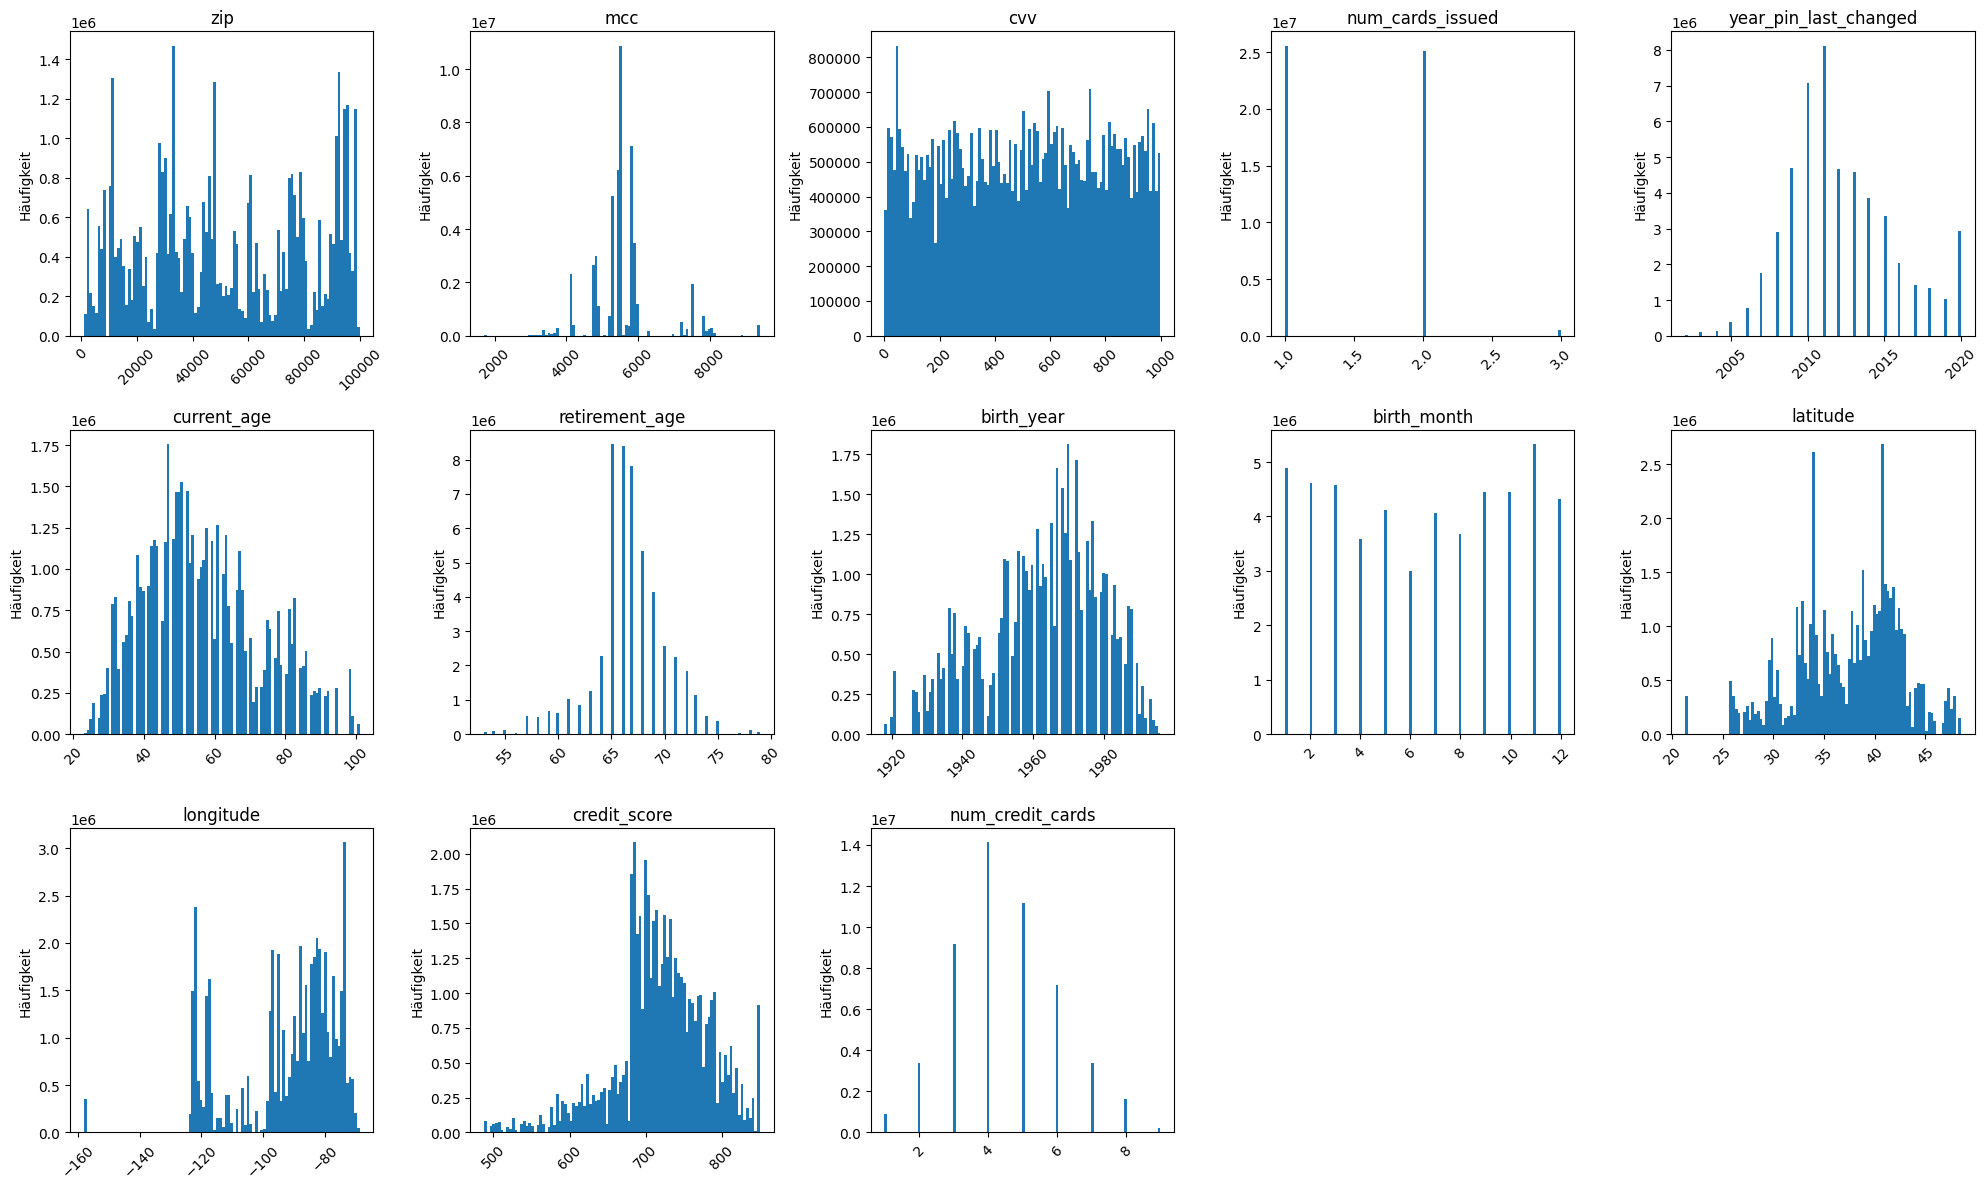

In [26]:
# Histogramm: Numerischen Variablen

# ID-Variablen nicht anzeigen, da sie zu viele unterschiedliche Werte besitzen
# und keine inhaltlich relevante Information für die Analyse liefern
id_cols = [
    "id_transaction", "client_id", "card_id",
    "merchant_id", "id_cards", "id_user", "card_number",
]
numerical_var = [
    col for col in numerical_var
    # ID-Spalten nicht betrachten (kein Informationsgehalt)
    if col not in id_cols
]

n_cols = 5
n_rows = math.ceil(len(numerical_var) / n_cols)
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(20, 4*n_rows)
)
axes = axes.flatten()

for i, col in enumerate(numerical_var):
    axes[i].hist(df_transactions[col], bins=100)
    axes[i].set_title(col)
    axes[i].set_ylabel("Häufigkeit")
    axes[i].tick_params(axis="x", rotation=45)

# Leere Subplots entfernen
for j in range(len(numerical_var), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

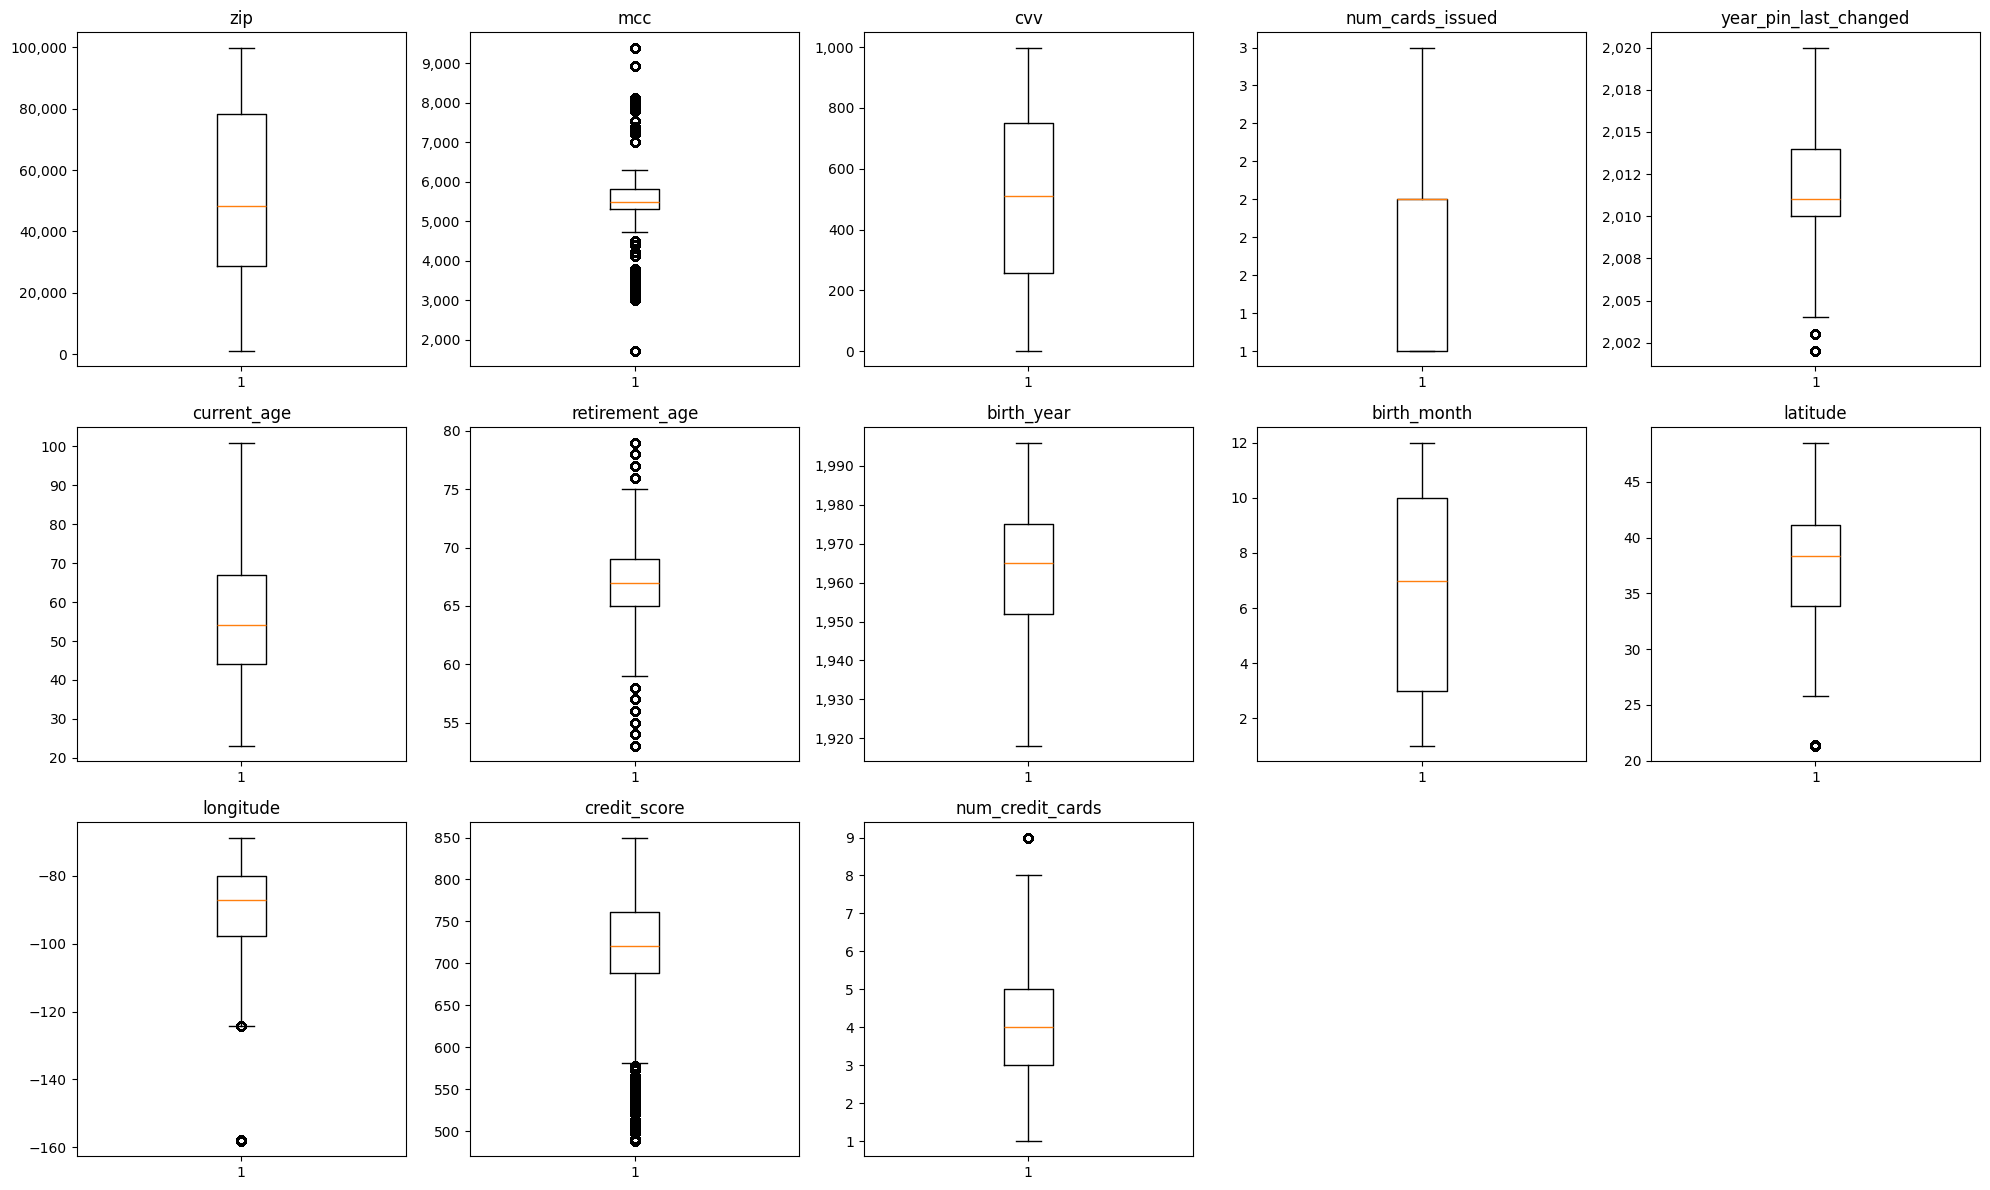

In [27]:
# Boxplot: Numerischen Variablen

n_cols = 5  # Anzahl der Plots
n_rows = math.ceil(len(numerical_var) / n_cols)
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(20, 4*n_rows)
)
axes = axes.flatten()

for i, col in enumerate(numerical_var):
    axes[i].boxplot(df_transactions[col].dropna())  # Boxplot
    axes[i].set_title(col)
    axes[i].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

# Leere Subplots entfernen
for j in range(len(numerical_var), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

**Interpretation**

Die Variable **zip** sollte als String gespeichert werden, da es sich um einen kategorialen Identifier handelt. Die Verteilung ist breit gestreut und zeigt keine starke regionale Häufung. 

Der Boxplot zur Variable **mcc** zeigt eine Konzentration der Werte um 5.000–6.000 mit zahlreichen Ausreißern nach oben und unten. Das Histogramm verdeutlicht, dass ein einzelner MCC-Code stark dominiert, während die übrigen Codes deutlich seltener auftreten. Da der MCC-Code die numerische Entsprechung der Beschreibungs-Variable (description) ist, wird für die Analyse lediglich die Beschreibungs-Variable beibehalten.

Der Boxplot zur Variable **cvv** zeigt eine nahezu gleichmäßige Verteilung über den gesamten Wertebereich, welche durch das Histogramm bestätigt wird. Der CVV ist eine zufällig generierte Sicherheitsnummer ohne Bezug zum Transaktionsverhalten und liefert keinen Beitrag zur Erkennung zeitlicher Verhaltensmuster. Diese Variable sollte entfernt werden.

Aus den Grafiken zu der Variable **num_cards_issued** geht hervor, dass die meisten Kunden ein bis zwei Karten pro Konto besitzen. 

Die häufigsten letzten Änderungen des Kartenpins (**year_pin_last_changed**) fanden zwischen 2010 und 2015 statt.

Die Grafiken zur **current_age** zeigen, dass die Kunden überwiegend mittleren bis höheren Alters sind (40–65 Jahre), während jüngere Kunden unter 30 und sehr alte über 80 eher unterrepräsentiert sind. Da das Alter aus dem Geburtsjahr abgeleitet werden kann, sind beide Variablen redundant. Es wird lediglich die Variable birth_year beibehalten und current_age entfernt.

Durch die Variable **retirement_age** geht hervor, dass die meisten Kunden zwischen dem Alter von 65 und 67 in die Rente gehen. Zudem weist die Variable eine geringe Varianz auf. Da es sich um ein weitgehend standardisiertes Rentenalter handelt, liefert diese Variable keinen Beitrag zur Erkennung unterschiedlicher Verhaltensmuster und sollte entfernt werden.

Die Geburtsjahre (**birth_year**) häufen sich in den Jahren 1950 bis 1975, was konsistent mit dem beobachteten Altersprofil ist. 

Es liegt eine gleichmäßige Verteilung über alle 12 Monate der Variable **birth_month** vor. Lediglich in den Sommermonaten sinkt die Anzahl etwas.

Die geografischen Variablen **latitude** und **longitude** sind statische Kundenmerkmale und liefern keinen Beitrag zur Analyse zeitlicher Verhaltensmuster. Für die geografische Zuordnung wird stattdessen die Variable zip verwendet. Beide Variablen sollten entfernt werden.

Die Variable **credit_score** häuft sich bei Werten von 650 bis 750, was auf Standardkunden mit guter Bonität hindeutet. Gleichzeitig ist ein sichtbarer Ausreißerblock bei etwa 500 erkennbar, der eine Minderheit von Kunden mit schlechter Bonität repräsentiert.

Die Grafiken zu der Variable **num_credit_cards** zeigen, dass der Median bei etwa 4 Kreditkarten liegt, wobei die häufigsten Werte zwischen 1 und 5 auftreten. Vereinzelte Ausreißer sind bei 9 Kreditkarten erkennbar.

### Korrelationsmatrix

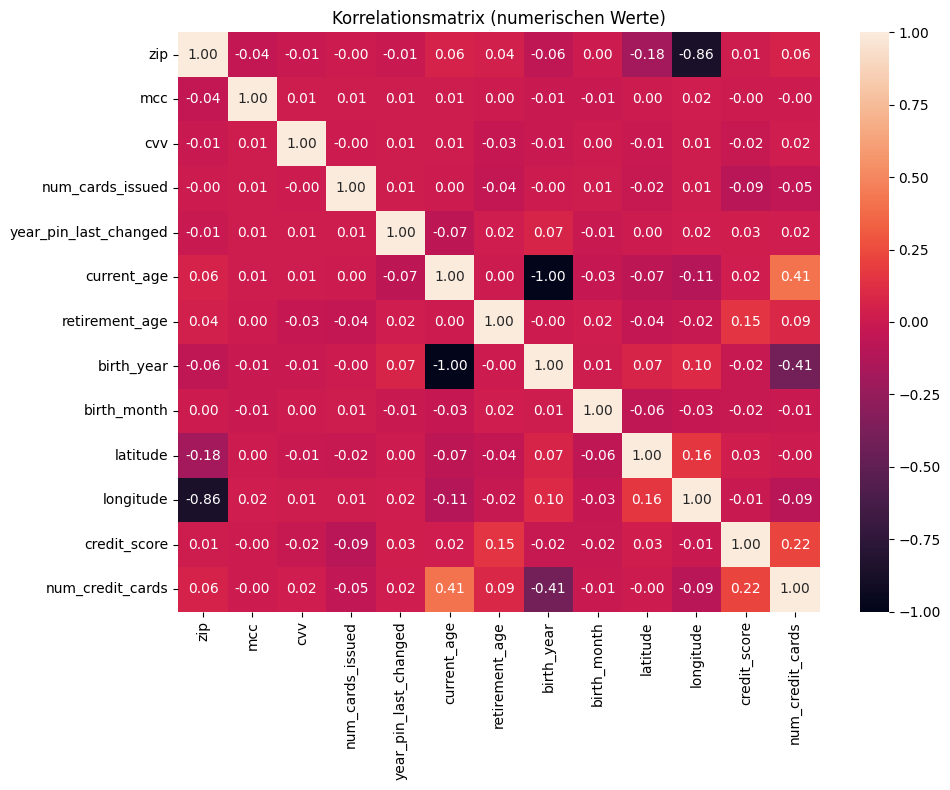

In [28]:
# Korrelationsmatrix: Numerischen Variablen
correlation_matrix = (
    df_transactions[numerical_var]
    .corr(method="pearson")
    .round(2))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,  # Werte anzeigen
    fmt=".2f",  # Auf 2 Nachkommastellen anpassen
    ax=ax
)
ax.set_title("Korrelationsmatrix (numerischen Werte)")
plt.tight_layout()
plt.show()

**Interpretation**

Die Variablen **current_age** und **birth_year** weisen eine sehr hohe negative Korrelation (-1) auf. Dies ist erwartbar, da das Alter direkt aus dem Geburtsjahr berechnet wird. Beide Variablen enthalten somit dieselbe Information. Die Variable **current_age** sollte gelöscht werden, da man aus der Variable **birth_year** auch das Alter bestimmen kann.

Die Variablen **longitude** und **zip** weisen ebenfalls eine relativ starke negative Korrelation (-0.86) auf. Dies ist ebenfalls plausibel, da Postleitzahlen geografisch organisiert sind und daher mit dem Längengrad zusammenhängen. Regionen mit ähnlichen Postleitzahlen liegen auch in ähnlichen geografischen Bereichen.

Eine moderate positive Korrelation (0.41) weisen die Variablen **num_credit_cards** und **current_age** auf. Dies lässt sich so interpretieren, dass ältere Personen im Durchschnitt mehr Kreditkarten besitzen. Eine mögliche Erklärung ist eine längere Kredit- und Bankhistorie, die im Laufe des Lebens zur Nutzung mehrerer Finanzprodukte führt.

Entsprechend zeigt sich auch zwischen **num_credit_cards** und **birth_year** eine moderate negative Korrelation (-0.41). Dies ist konsistent mit der vorherigen Beobachtung, da ein höheres Geburtsjahr jüngere Personen beschreibt, die durchschnittlich weniger Kreditkarten besitzen.

Zwischen **credit_score** und **num_credit_cards** besteht eine schwache positive Korrelation (0.22). Dies könnte darauf hindeuten, dass Personen mit mehreren Kreditkarten tendenziell einen etwas höheren Kredit-Score aufweisen, möglicherweise aufgrund einer längeren Kreditgeschichte oder einer stärkeren Nutzung von Kreditprodukten.

Die meisten übrigen Variablenpaare weisen hingegen nur sehr geringe Korrelationen auf (Werte nahe 0), was darauf hindeutet, dass zwischen diesen Variablen kein starker linearer Zusammenhang besteht.

### Fehlende Werte (Grafik)

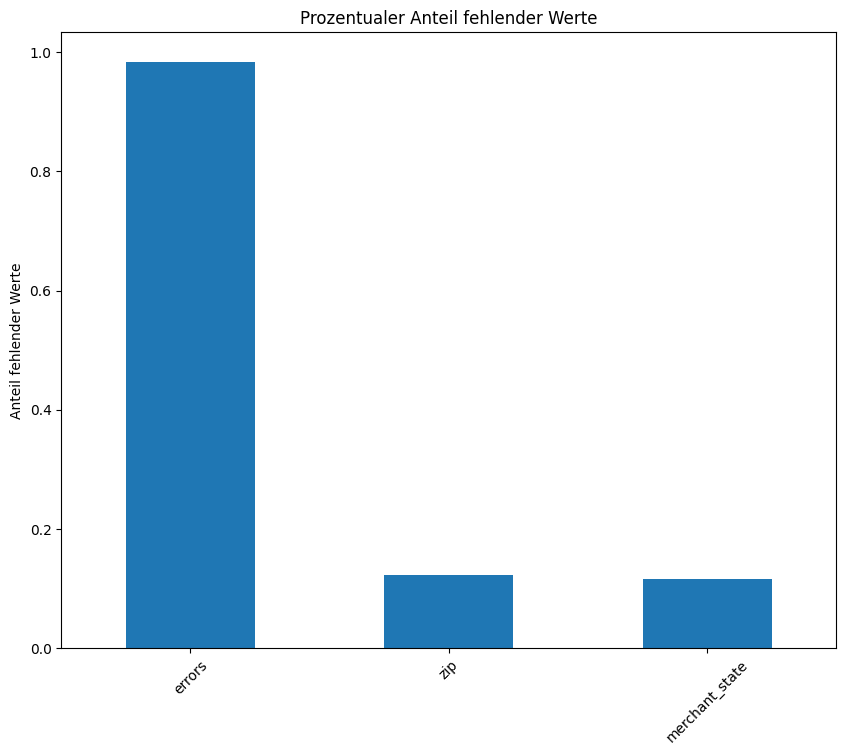

In [29]:
# Bestimmung des Anteils der fehlenden Werte pro Variable
missing_ratio = df_transactions.isna().mean()
missing_ratio = missing_ratio[missing_ratio > 0].sort_values(ascending=False)

# Barplot: Fehlende Werte in Prozent
plt.figure(figsize=(10, 8))
missing_ratio.plot(kind='bar')
plt.ylabel("Anteil fehlender Werte")
plt.title("Prozentualer Anteil fehlender Werte")
plt.xticks(rotation=45)
plt.show()

**Interpretation**

Aus der Grafik geht hervor, dass die Variable **errors** in fast allen Datensätzen fehlende Werte aufweist. Der Anteil der fehlenden Einträge deuten darauf hin, dass diese als "keine Fehler" interpretiert werden können. 

Darüber hinaus zeigen die Variablen **zip** und **merchant_state** fehlende Werte auf in der gleichen Höhe auf. Insgesamt handelt es sich hierbei jedoch nur um einen geringen Anteil, sodass keine systematische Häufung erkennbar ist.

***
***